1. 向量点积 $a⋅b$
$$a⋅b=2×1+(−1)×4+3×(−2)$$
$$=2−4−6=−8$$

2. 矩阵乘法 $A×B$
$$A \times B =
\begin{bmatrix}
1 & 0 & 2 \\
-1 & 3 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 1 \\
0 & -1 \\
3 & 2
\end{bmatrix}$$
因此：
$$
A \times B =
\begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}
$$

3. 向量 $a$ 的 Frobenius 范数
$$
\|\mathbf{a}\|_F = \sqrt{2^2 + (-1)^2 + 3^2}
= \sqrt{4 + 1 + 9}
= \sqrt{14}
$$

In [1]:
import numpy as np

# 1. 创建一个形状为 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)  # 设置随机种子，保证结果可重复
X = np.random.randn(3, 4)
print("矩阵 X (3x4，标准正态分布):")
print(X)
print()

# 2. 创建一个形状为 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("矩阵 Y (4x2，全1矩阵):")
print(Y)
print()

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  # 或者 X @ Y
print("矩阵乘法 Z = X × Y (形状 3x2):")
print(Z)
print()

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
# 注意：Python索引从0开始，第一行是索引0，第二列是索引1，第二行是索引1
element_row1_col2 = Z[0, 1]  # 第一行第二列
row2 = Z[1, :]               # 第二行所有元素

print("Z 的第一行第二列交叉处的元素:", element_row1_col2)
print("Z 的第二行所有元素:", row2)
print()

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')  # 或 np.sqrt(np.sum(Z**2))
print("Z 的 Frobenius 范数:", frobenius_norm)

矩阵 X (3x4，标准正态分布):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

矩阵 Y (4x2，全1矩阵):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵乘法 Z = X × Y (形状 3x2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z 的第一行第二列交叉处的元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]

Z 的 Frobenius 范数: 4.616873319476863


# 3.1理论计算题

$$
P(\text{阳性}) = 0.99 \times 0.001 + 0.02 \times 0.999 = 0.00099 + 0.01998 = 0.02097
$$

$$
P(\text{患病} \mid \text{阳性}) = \frac{0.99 \times 0.001}{0.02097} = \frac{0.00099}{0.02097} \approx 0.04721 \approx 4.72\%
$$


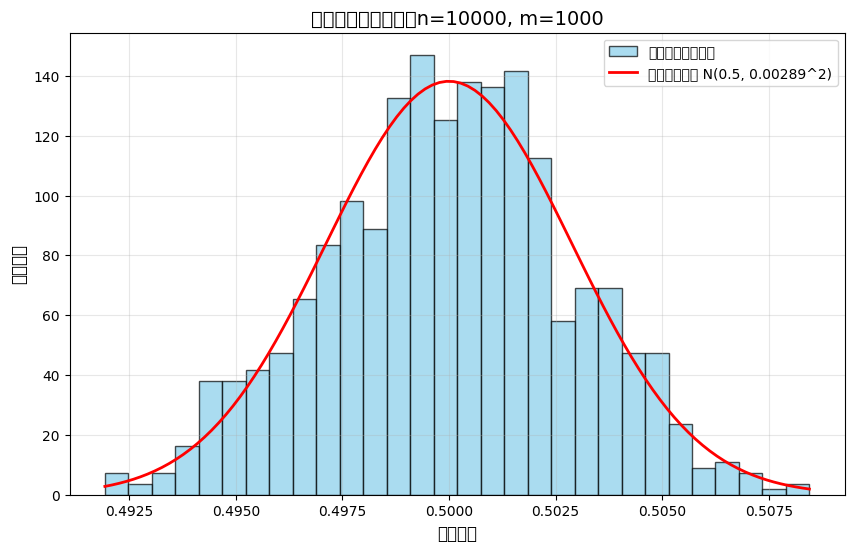

实际方差（由模拟数据计算）: 0.00000828
理论方差（均匀分布方差除以 n）: 0.00000833
相对误差: 0.6924%


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置参数
n = 10000      # 每次抽取的样本量
m = 1000       # 重复次数

# 1. 生成 m 个均值
np.random.seed(42)  # 保证结果可重复
means = []

for _ in range(m):
    sample = np.random.uniform(0, 1, n)  # 从 U(0,1) 中抽取 n 个样本
    means.append(np.mean(sample))        # 计算均值并保存

means = np.array(means)

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))

# 绘制直方图（密度直方图，便于与概率密度曲线比较）
count, bins, patches = plt.hist(means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='样本均值的直方图')

# 理论正态分布：均值 = 0.5，方差 = (1/12) / n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)  # 均匀分布的方差为 1/12
x = np.linspace(min(means), max(means), 100)
y = norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, y, 'r-', linewidth=2, label=f'理论正态分布 N({mu_theory}, {sigma_theory:.5f}^2)')

# 图表设置
plt.xlabel('样本均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title(f'中心极限定理验证：n={n}, m={m}', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_variance = np.var(means, ddof=0)  # ddof=0 表示计算总体方差
theoretical_variance = (1/12) / n

print(f"实际方差（由模拟数据计算）: {actual_variance:.8f}")
print(f"理论方差（均匀分布方差除以 n）: {theoretical_variance:.8f}")
print(f"相对误差: {abs(actual_variance - theoretical_variance) / theoretical_variance * 100:.4f}%")

# 4.1 理论计算题

1. 求偏导表达式
令  
$$
u = w_1 x_1 + w_2 x_2 - y
$$  
则 $z = u^2$。

由链式法则：  
$$
\frac{\partial z}{\partial w_1} = \frac{\partial z}{\partial u} \cdot \frac{\partial u}{\partial w_1} = 2u \cdot x_1 = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1
$$  
$$
\frac{\partial z}{\partial w_2} = \frac{\partial z}{\partial u} \cdot \frac{\partial u}{\partial w_2} = 2u \cdot x_2 = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2
$$

代入 $x_1 = 2$, $x_2 = 1$, $y = 3$：  
$$
\frac{\partial z}{\partial w_1} = 2(w_1 \cdot 2 + w_2 \cdot 1 - 3) \cdot 2 = 4(2w_1 + w_2 - 3)
$$  
$$
\frac{\partial z}{\partial w_2} = 2(w_1 \cdot 2 + w_2 \cdot 1 - 3) \cdot 1 = 2(2w_1 + w_2 - 3)
$$

2. 计算梯度值

代入 $w_1 = 0.5$, $w_2 = 1$：

先计算括号内的值：  
$$
2w_1 + w_2 - 3 = 2 \times 0.5 + 1 - 3 = 1 + 1 - 3 = -1
$$

则：  
$$
\frac{\partial z}{\partial w_1} = 4 \times (-1) = -4
$$  
$$
\frac{\partial z}{\partial w_2} = 2 \times (-1) = -2
$$

梯度为：  
$$
\nabla z = \left[ \frac{\partial z}{\partial w_1}, \frac{\partial z}{\partial w_2} \right] = [-4, -2]
$$

In [4]:
import torch

# ==================== 1. 定义前向计算 ====================
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 计算前向结果
L, a, b = forward(x, w1, w2)
print("=" * 50)
print("前向计算结果")
print("=" * 50)
print(f"x = {x}, w1 = {w1}, w2 = {w2}")
print(f"a = x * w1 = {x} * {w1} = {a}")
print(f"b = a + w2 = {a} + {w2} = {b}")
print(f"L = b^2 = {b}^2 = {L}")
print()

# ==================== 2. 手动反向传播（链式法则） ====================
print("=" * 50)
print("手动反向传播计算梯度")
print("=" * 50)

# 前向过程中的中间值
a = x * w1      # a = 2 * 1.5 = 3
b = a + w2      # b = 3 + 0.5 = 3.5

# 链式法则：
# dL/db = 2 * b
dL_db = 2 * b
print(f"dL/db = 2 * b = 2 * {b} = {dL_db}")

# db/da = 1
# dL/da = dL/db * db/da = dL/db * 1 = dL/db
dL_da = dL_db * 1
print(f"dL/da = dL/db * db/da = {dL_db} * 1 = {dL_da}")

# da/dw1 = x
# dL/dw1 = dL/da * da/dw1 = dL/da * x
dL_dw1 = dL_da * x
print(f"dL/dw1 = dL/da * da/dw1 = {dL_da} * {x} = {dL_dw1}")

# db/dw2 = 1
# dL/dw2 = dL/db * db/dw2 = dL/db * 1 = dL/db
dL_dw2 = dL_db * 1
print(f"dL/dw2 = dL/db * db/dw2 = {dL_db} * 1 = {dL_dw2}")

print()
print(f"手动计算梯度结果：")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}")
print()

# ==================== 3. 使用 PyTorch 自动微分验证 ====================
print("=" * 50)
print("PyTorch 自动微分验证")
print("=" * 50)

# 创建张量，requires_grad=True 表示需要计算梯度
x_t = torch.tensor(2.0, requires_grad=False)  # x 是常数，不需要梯度
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

# 前向传播
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"前向结果：L = {L_t.item()}")
print(f"PyTorch 计算的梯度：")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}")
print()

# ==================== 4. 结果对比 ====================
print("=" * 50)
print("结果验证")
print("=" * 50)

print(f"手动计算 ∂L/∂w1 = {dL_dw1}")
print(f"PyTorch ∂L/∂w1 = {w1_t.grad.item()}")
print(f"是否一致：{'✓ 一致' if abs(dL_dw1 - w1_t.grad.item()) < 1e-6 else '✗ 不一致'}")
print()
print(f"手动计算 ∂L/∂w2 = {dL_dw2}")
print(f"PyTorch ∂L/∂w2 = {w2_t.grad.item()}")
print(f"是否一致：{'✓ 一致' if abs(dL_dw2 - w2_t.grad.item()) < 1e-6 else '✗ 不一致'}")

前向计算结果
x = 2.0, w1 = 1.5, w2 = 0.5
a = x * w1 = 2.0 * 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b^2 = 3.5^2 = 12.25

手动反向传播计算梯度
dL/db = 2 * b = 2 * 3.5 = 7.0
dL/da = dL/db * db/da = 7.0 * 1 = 7.0
dL/dw1 = dL/da * da/dw1 = 7.0 * 2.0 = 14.0
dL/dw2 = dL/db * db/dw2 = 7.0 * 1 = 7.0

手动计算梯度结果：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

PyTorch 自动微分验证
前向结果：L = 12.25
PyTorch 计算的梯度：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

结果验证
手动计算 ∂L/∂w1 = 14.0
PyTorch ∂L/∂w1 = 14.0
是否一致：✓ 一致

手动计算 ∂L/∂w2 = 7.0
PyTorch ∂L/∂w2 = 7.0
是否一致：✓ 一致


# 5.1 理论计算题

1. 对 $w$ 求偏导

$$
\frac{\partial L}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{1}{n} \sum_{i=1}^n (y_i - wx_i - b)^2 \right]
$$

由于求导与求和可交换顺序：

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n \frac{\partial}{\partial w} (y_i - wx_i - b)^2
$$

令 $u = y_i - wx_i - b$，则 $\frac{\partial}{\partial w} u^2 = 2u \cdot \frac{\partial u}{\partial w} = 2(y_i - wx_i - b) \cdot (-x_i)$

因此：

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - wx_i - b) \cdot (-x_i)
$$

$$
\frac{\partial L}{\partial w} = -\frac{2}{n} \sum_{i=1}^n x_i (y_i - wx_i - b)
$$

2. 对 $b$ 求偏导

$$
\frac{\partial L}{\partial b} = \frac{\partial}{\partial b} \left[ \frac{1}{n} \sum_{i=1}^n (y_i - wx_i - b)^2 \right]
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n \frac{\partial}{\partial b} (y_i - wx_i - b)^2
$$

令 $u = y_i - wx_i - b$，则 $\frac{\partial}{\partial b} u^2 = 2u \cdot \frac{\partial u}{\partial b} = 2(y_i - wx_i - b) \cdot (-1)$

因此：

$$
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n 2(y_i - wx_i - b) \cdot (-1)
$$

$$
\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^n (y_i - wx_i - b)
$$

1. 加载数据
训练集大小: 1437 样本
测试集大小: 360 样本
特征维度: 64
类别数: 10

2. One-hot 编码
训练标签 one-hot 编码形状: (1437, 10)
示例: 标签 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

3. Softmax 回归实现
4. 训练模型
批量大小: 32
学习率: 0.1
训练轮数: 50
每轮的批次数: 45

Epoch 10/50 | Loss: 0.1349 | Train Acc: 0.9805 | Test Acc: 0.9611
Epoch 20/50 | Loss: 0.0890 | Train Acc: 0.9868 | Test Acc: 0.9556
Epoch 30/50 | Loss: 0.0693 | Train Acc: 0.9903 | Test Acc: 0.9639
Epoch 40/50 | Loss: 0.0577 | Train Acc: 0.9916 | Test Acc: 0.9639
Epoch 50/50 | Loss: 0.0499 | Train Acc: 0.9965 | Test Acc: 0.9667

训练完成！

5. 最终结果
训练集准确率: 0.9965 (99.65%)
测试集准确率: 0.9667 (96.67%)



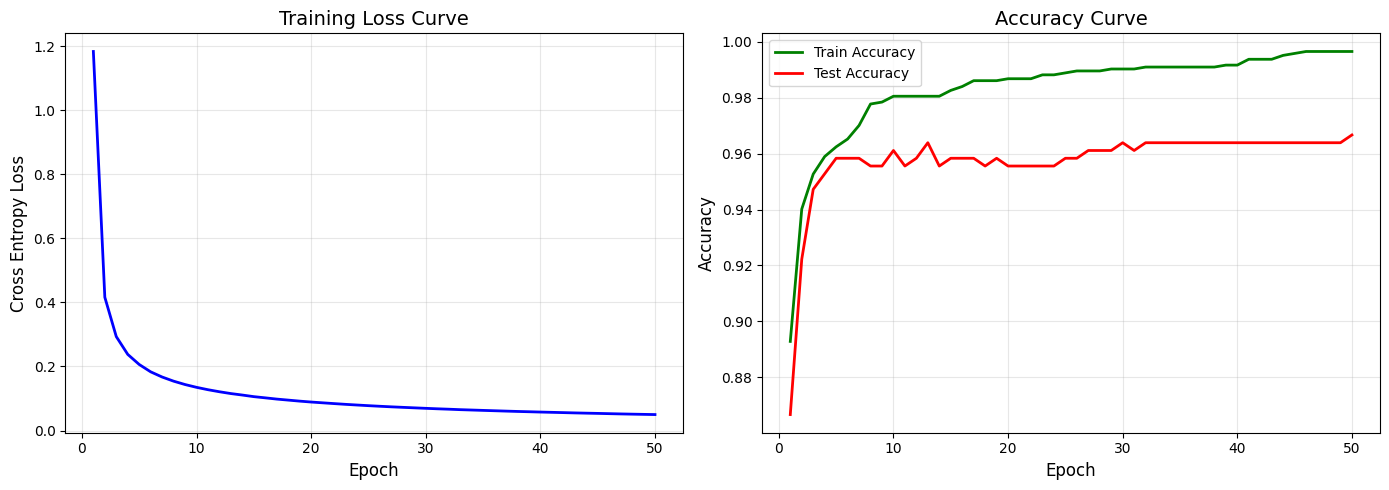

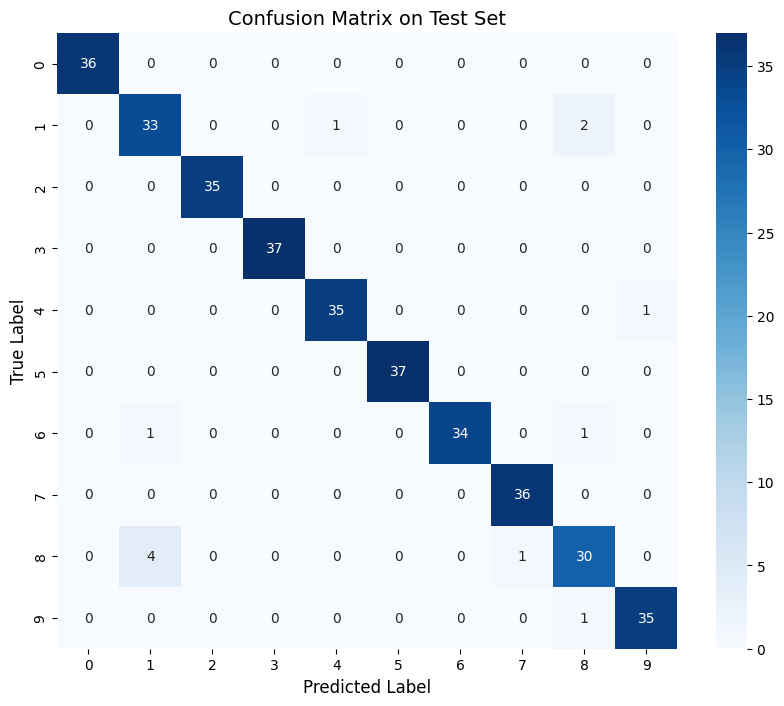

In [6]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==================== 1. 加载数据 ====================
print("=" * 50)
print("1. 加载数据")
print("=" * 50)

digits = load_digits()
X = digits.images  # 形状: (1797, 8, 8)
y = digits.target  # 形状: (1797,)

# 将图像展平为向量 (8x8 = 64 维)
X = X.reshape(X.shape[0], -1)  # 形状: (1797, 64)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 数据标准化（有助于梯度下降收敛）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"特征维度: {X_train.shape[1]}")
print(f"类别数: {len(np.unique(y))}")
print()

# ==================== 2. One-hot 编码 ====================
print("=" * 50)
print("2. One-hot 编码")
print("=" * 50)

def one_hot_encoding(y, num_classes):
    """将标签转换为 one-hot 编码"""
    n = len(y)
    one_hot = np.zeros((n, num_classes))
    one_hot[np.arange(n), y] = 1
    return one_hot

num_classes = 10
y_train_onehot = one_hot_encoding(y_train, num_classes)
y_test_onehot = one_hot_encoding(y_test, num_classes)

print(f"训练标签 one-hot 编码形状: {y_train_onehot.shape}")
print(f"示例: 标签 {y_train[0]} -> {y_train_onehot[0]}")
print()

# ==================== 3. Softmax 回归实现 ====================
print("=" * 50)
print("3. Softmax 回归实现")
print("=" * 50)

class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, learning_rate=0.1):
        """
        初始化参数
        input_dim: 输入特征维度
        num_classes: 类别数
        learning_rate: 学习率
        """
        # 使用 Xavier 初始化
        self.W = np.random.randn(input_dim, num_classes) * np.sqrt(2.0 / input_dim)
        self.b = np.zeros(num_classes)
        self.lr = learning_rate
        
    def softmax(self, logits):
        """Softmax 函数，对每一行进行 softmax"""
        # 减去最大值防止数值溢出
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, y_pred, y_true):
        """交叉熵损失函数"""
        n = y_pred.shape[0]
        # 避免 log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.sum(y_true * np.log(y_pred)) / n
        return loss
    
    def forward(self, X):
        """前向传播"""
        logits = X @ self.W + self.b  # (n, num_classes)
        return self.softmax(logits)
    
    def backward(self, X, y_pred, y_true):
        """反向传播计算梯度"""
        n = X.shape[0]
        # 梯度计算: dL/dlogits = y_pred - y_true
        grad_logits = y_pred - y_true  # (n, num_classes)
        
        # 计算参数梯度
        grad_W = (X.T @ grad_logits) / n  # (input_dim, num_classes)
        grad_b = np.mean(grad_logits, axis=0)  # (num_classes,)
        
        return grad_W, grad_b
    
    def update(self, grad_W, grad_b):
        """更新参数"""
        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b
    
    def predict(self, X):
        """预测类别"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# ==================== 4. 训练模型 ====================
print("=" * 50)
print("4. 训练模型")
print("=" * 50)

# 超参数
batch_size = 32
learning_rate = 0.1
epochs = 50

# 初始化模型
model = SoftmaxRegression(
    input_dim=X_train.shape[1],
    num_classes=num_classes,
    learning_rate=learning_rate
)

# 训练过程
n_samples = X_train.shape[0]
n_batches = (n_samples + batch_size - 1) // batch_size

train_losses = []
train_accs = []
test_accs = []

print(f"批量大小: {batch_size}")
print(f"学习率: {learning_rate}")
print(f"训练轮数: {epochs}")
print(f"每轮的批次数: {n_batches}")
print()

for epoch in range(epochs):
    # 每个 epoch 前打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    
    # 小批量梯度下降
    for i in range(0, n_samples, batch_size):
        # 获取一个小批量
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        y_pred = model.forward(X_batch)
        
        # 计算损失
        loss = model.cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss * len(X_batch)
        
        # 反向传播
        grad_W, grad_b = model.backward(X_batch, y_pred, y_batch)
        
        # 更新参数
        model.update(grad_W, grad_b)
    
    # 计算平均损失
    epoch_loss /= n_samples
    train_losses.append(epoch_loss)
    
    # 计算训练和测试准确率
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    # 每 10 个 epoch 输出一次
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print()
print("训练完成！")
print()

# ==================== 5. 输出测试集准确率 ====================
print("=" * 50)
print("5. 最终结果")
print("=" * 50)

final_train_acc = model.accuracy(X_train, y_train)
final_test_acc = model.accuracy(X_test, y_test)

print(f"训练集准确率: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"测试集准确率: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")
print()

# ==================== 可视化（可选） ====================
import matplotlib.pyplot as plt

# 绘制损失曲线和准确率曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(range(1, epochs+1), train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross Entropy Loss', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=14)
axes[0].grid(alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, epochs+1), train_accs, 'g-', label='Train Accuracy', linewidth=2)
axes[1].plot(range(1, epochs+1), test_accs, 'r-', label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curve', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 输出混淆矩阵（可选）
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_test = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix on Test Set', fontsize=14)
plt.show()

# 6.1 理论计算题

 1. 似然函数

正态分布的概率密度函数为：
$$
f(x_i; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

由于样本独立，似然函数为各密度函数的乘积：
$$
L(\mu, \sigma^2) = \prod_{i=1}^n f(x_i; \mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)
$$

即：
$$
L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2\right)
$$

2. 证明 $\mu$ 的最大似然估计

取对数似然函数：
$$
\ell(\mu, \sigma^2) = \ln L(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2
$$

对 $\mu$ 求偏导：
$$
\frac{\partial \ell}{\partial \mu} = -\frac{1}{2\sigma^2} \cdot 2 \sum_{i=1}^n (x_i - \mu) \cdot (-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu)
$$

令偏导数为 0：
$$
\frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0 \quad \Rightarrow \quad \sum_{i=1}^n (x_i - \mu) = 0
$$

$$
\sum_{i=1}^n x_i - n\mu = 0 \quad \Rightarrow \quad \hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i
$$

二阶导数 $\frac{\partial^2 \ell}{\partial \mu^2} = -\frac{n}{\sigma^2} < 0$，确认为最大值。

3. 证明 $\sigma^2$ 的最大似然估计

令 $\theta = \sigma^2$，对数似然函数为：
$$
\ell(\mu, \theta) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln \theta - \frac{1}{2\theta} \sum_{i=1}^n (x_i - \mu)^2
$$

对 $\theta$ 求偏导：
$$
\frac{\partial \ell}{\partial \theta} = -\frac{n}{2} \cdot \frac{1}{\theta} + \frac{1}{2\theta^2} \sum_{i=1}^n (x_i - \mu)^2 = -\frac{n}{2\theta} + \frac{1}{2\theta^2} \sum_{i=1}^n (x_i - \mu)^2
$$

令偏导数为 0：
$$
-\frac{n}{2\theta} + \frac{1}{2\theta^2} \sum_{i=1}^n (x_i - \mu)^2 = 0
$$

两边乘以 $2\theta^2$：
$$
-n\theta + \sum_{i=1}^n (x_i - \mu)^2 = 0 \quad \Rightarrow \quad \hat{\theta} = \frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2
$$

将 $\mu$ 替换为其 MLE $\hat{\mu} = \frac{1}{n}\sum x_i$：
$$
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2
$$

1. 生成线性可分数据
训练集大小: 400 样本
特征维度: 2
类别分布: 类别0 = 200, 类别1 = 200



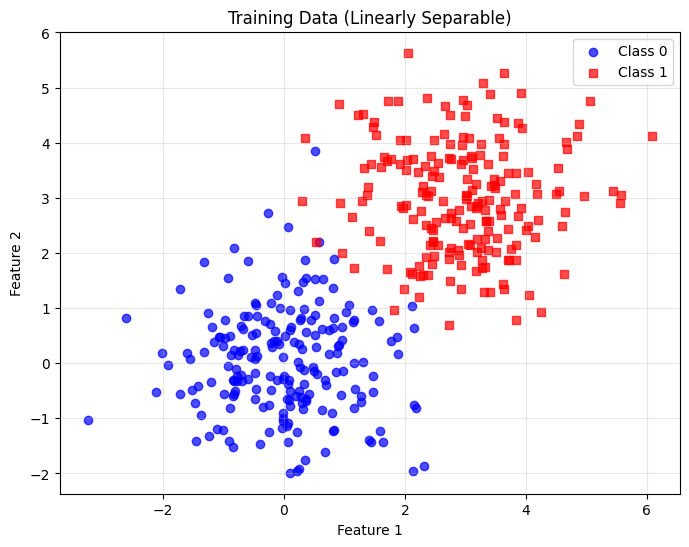

2. 定义 Sigmoid 和二元交叉熵损失
Sigmoid 测试: [-2  0  2] -> [0.11920292 0.5        0.88079708]

3. 训练逻辑回归模型
Iteration 100/1000 | Loss: 0.2001
Iteration 200/1000 | Loss: 0.1392
Iteration 300/1000 | Loss: 0.1123
Iteration 400/1000 | Loss: 0.0970
Iteration 500/1000 | Loss: 0.0870
Iteration 600/1000 | Loss: 0.0799
Iteration 700/1000 | Loss: 0.0746
Iteration 800/1000 | Loss: 0.0704
Iteration 900/1000 | Loss: 0.0671
Iteration 1000/1000 | Loss: 0.0643

训练完成！



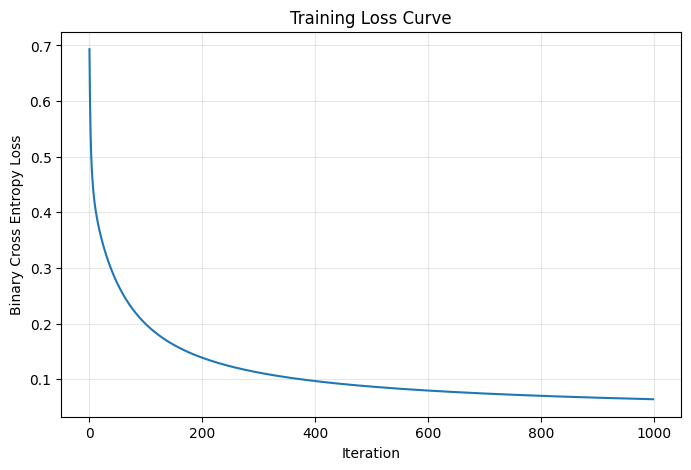

4. 决策边界和测试集评估
测试集大小: 100 样本
测试集准确率: 0.9900 (99.00%)



C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_15028\4281260184.py:181: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(X_test_plot[y_test_plot == 0, 0], X_test_plot[y_test_plot == 0, 1],
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_15028\4281260184.py:184: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(X_test_plot[y_test_plot == 1, 0], X_test_plot[y_test_plot == 1, 1],
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_15028\4281260184.py:203: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z_proba, levels=[0.5], colors='green', linewidths=2,


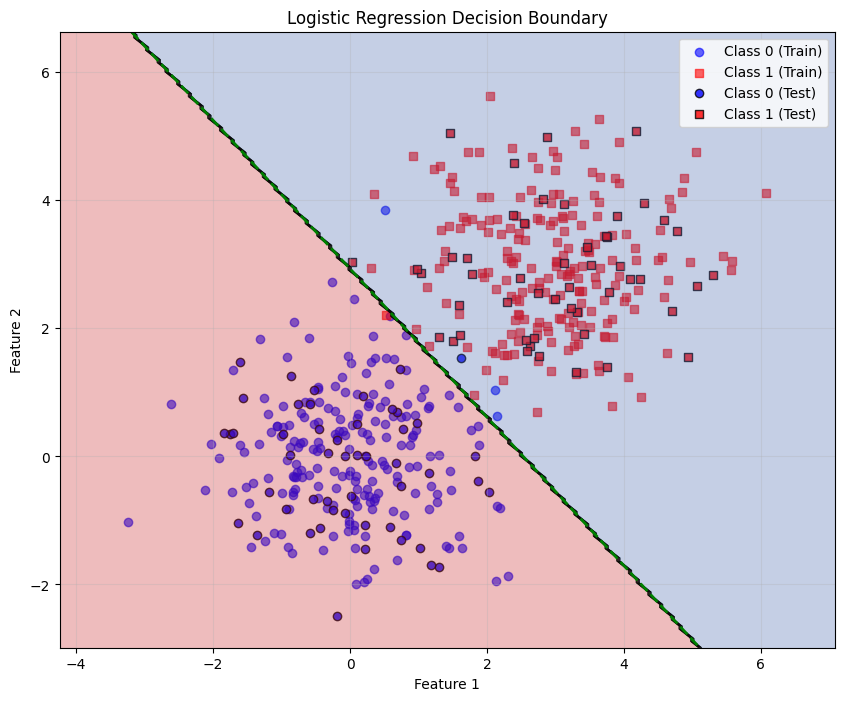

模型参数
权重 w: [1.6362, 1.4119]
偏置 b: -4.1383

决策边界方程: 1.6362 * x1 + 1.4119 * x2 + -4.1383 = 0


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. 生成线性可分数据 ====================
print("=" * 50)
print("1. 生成线性可分数据")
print("=" * 50)

def generate_linear_separable_data(n_samples=200, random_state=42):
    """生成两类线性可分的数据，特征维度为2"""
    np.random.seed(random_state)
    
    # 类别 0：均值为 (0, 0)，协方差矩阵为单位矩阵
    X0 = np.random.randn(n_samples // 2, 2)
    y0 = np.zeros(n_samples // 2)
    
    # 类别 1：均值为 (3, 3)，协方差矩阵为单位矩阵
    X1 = np.random.randn(n_samples // 2, 2) + 3
    y1 = np.ones(n_samples // 2)
    
    # 合并数据
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

# 生成训练数据
X_train, y_train = generate_linear_separable_data(n_samples=400, random_state=42)
print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"特征维度: {X_train.shape[1]}")
print(f"类别分布: 类别0 = {np.sum(y_train == 0)}, 类别1 = {np.sum(y_train == 1)}")
print()

# 可视化训练数据
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
            c='blue', marker='o', label='Class 0', alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
            c='red', marker='s', label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data (Linearly Separable)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==================== 2. 定义 Sigmoid 函数和二元交叉熵损失 ====================
print("=" * 50)
print("2. 定义 Sigmoid 和二元交叉熵损失")
print("=" * 50)

def sigmoid(z):
    """Sigmoid 函数，将输入映射到 (0, 1) 区间"""
    # 防止数值溢出
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    """二元交叉熵损失函数
    y_true: 真实标签 (0 或 1)
    y_pred: 预测概率 (sigmoid 输出)
    """
    eps = 1e-15  # 防止 log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# 测试函数
test_z = np.array([-2, 0, 2])
print(f"Sigmoid 测试: {test_z} -> {sigmoid(test_z)}")
print()

# ==================== 3. 梯度下降法训练 ====================
print("=" * 50)
print("3. 训练逻辑回归模型")
print("=" * 50)

class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.w = np.zeros(n_features)
        self.b = 0
        
        # 梯度下降
        for i in range(self.n_iterations):
            # 前向传播
            linear_model = X @ self.w + self.b
            y_pred = sigmoid(linear_model)
            
            # 计算损失
            loss = binary_cross_entropy(y, y_pred)
            self.losses.append(loss)
            
            # 反向传播（计算梯度）
            dw = (1 / n_samples) * (X.T @ (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            # 打印进度
            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{self.n_iterations} | Loss: {loss:.4f}")
        
        return self
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = X @ self.w + self.b
        return sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def score(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 训练模型
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)
print()
print("训练完成！")
print()

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)
plt.show()

# ==================== 4. 绘制决策边界并测试 ====================
print("=" * 50)
print("4. 决策边界和测试集评估")
print("=" * 50)

# 生成测试集（新生成 100 个样本）
X_test, y_test = generate_linear_separable_data(n_samples=100, random_state=100)
print(f"测试集大小: {X_test.shape[0]} 样本")

# 计算测试准确率
test_accuracy = model.score(X_test, y_test)
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()

# 绘制决策边界
def plot_decision_boundary(model, X, y):
    """绘制决策边界"""
    plt.figure(figsize=(10, 8))
    
    # 绘制训练数据点
    plt.scatter(X[y == 0, 0], X[y == 0, 1], 
                c='blue', marker='o', label='Class 0 (Train)', alpha=0.6)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], 
                c='red', marker='s', label='Class 1 (Train)', alpha=0.6)
    
    # 绘制测试数据点（用不同形状）
    X_test_plot, y_test_plot = generate_linear_separable_data(n_samples=100, random_state=100)
    plt.scatter(X_test_plot[y_test_plot == 0, 0], X_test_plot[y_test_plot == 0, 1], 
                c='blue', marker='o', edgecolors='black', facecolors='none', 
                label='Class 0 (Test)', alpha=0.8)
    plt.scatter(X_test_plot[y_test_plot == 1, 0], X_test_plot[y_test_plot == 1, 1], 
                c='red', marker='s', edgecolors='black', facecolors='none', 
                label='Class 1 (Test)', alpha=0.8)
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5)
    
    # 绘制决策边界线（概率=0.5）
    Z_proba = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z_proba = Z_proba.reshape(xx.shape)
    plt.contour(xx, yy, Z_proba, levels=[0.5], colors='green', linewidths=2, 
                linestyles='dashed', label='Decision Boundary')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_train, y_train)

# 输出模型参数
print("=" * 50)
print("模型参数")
print("=" * 50)
print(f"权重 w: [{model.w[0]:.4f}, {model.w[1]:.4f}]")
print(f"偏置 b: {model.b:.4f}")
print()

# 决策边界方程: w0 * x1 + w1 * x2 + b = 0
print(f"决策边界方程: {model.w[0]:.4f} * x1 + {model.w[1]:.4f} * x2 + {model.b:.4f} = 0")